<a href="https://colab.research.google.com/github/sig-gis/cwcb-landcover-mapping/blob/main/00_Intial_Explorations/sam3_fast_classify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hard-coded concept classification with SAM 3, batch over a folder

The concept sets are written down, not discovered. Each class carries its definition, the types
under it, and the synonyms under each type. Every synonym is a text prompt; every detection keeps
its term, type and class, so results roll up at any of the three levels.

Run order: Cells 1 to 5 set the model and the concept input up once. Cell 6 declares the run scope
and where results land. Cells 7 and 8 define the per-scene work. Cell 9 runs every scene found.

Every scene in the sample folder is processed. Anything under a `nir` folder is skipped. Each
scene lands in its own folder on Drive holding four things: `instances.gpkg` (one polygon per
detection carrying class, type, term and score), `classes.tif` (those polygons burned to a class
raster, highest score winning any overlap), `detections.csv` (the same attributes flat, no
geometry), and `summary.json` (the scene's parameters, per class and type and term counts with
score statistics, the prompts that detected nothing, and timings). A run-level `manifest.csv`
records every scene's status.

Nothing scales with scene size in RAM. Tiles are cut to local disk and dropped when the scene
finishes, results are assembled per scene and copied to Drive, the class raster is burned one
block at a time, and both display reads are decimated. A scene that fails is logged and the run
continues to the next one. A finished scene is skipped on a re-run, so an interrupted run resumes
where it stopped.

Prompts are batched against one tile encoding: the vision encoder runs once per tile and the
embeddings are expanded across a batch of prompts, so a tile costs `ceil(len(PROMPTS)/PROMPT_BATCH)`
forwards rather than `len(PROMPTS)`.

In [1]:
# ── Cell 1: install ──
# Leaves torch alone, so a local ROCm build is untouched.
!pip -q install -U transformers accelerate huggingface_hub rasterio geopandas ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 154.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 148.7 MB/s eta 0:00:00


In [2]:
# ── Cell 2: imports, device, AOI discovery ──
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"]      = "expandable_segments:True"

import gc, colorsys, json, shutil, time, traceback
import numpy as np
import torch
import rasterio
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from rasterio.windows import Window
from rasterio.features import shapes as rio_shapes, rasterize
from shapely.geometry import shape as shp_shape
from shapely.ops import unary_union
from PIL import Image
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# The source scenes and nothing else. digitization_samples_nir is a sibling of this folder, so
# pointing one level down leaves NIR out by structure, with no filtering to get wrong.
DRIVE_AOI_DIR  = "/content/drive/MyDrive/digitization_samples_with_imagery-1/digitization_samples"
DRIVE_OUT_ROOT = "/content/drive/MyDrive/sam3_classified"   # results. Never an input.
WORK_DIR       = "/content/sam3_work"                       # scratch, local disk

OUTPUTS = ["instances.gpkg", "classes.tif", "detections.csv", "summary.json", "overlay.png"]

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("drive mount skipped:", e)

def discover_aois(base):
    """Every GeoTIFF under `base`, labelled by its path relative to base."""
    base = Path(base)
    if not base.exists():
        root = Path("/content/drive/MyDrive")
        hits = list(root.rglob(base.name)) if root.exists() else []
        base = hits[0] if hits else base
    tifs = sorted(list(base.rglob("*.tif")) + list(base.rglob("*.tiff")))
    out = []
    for t in tifs:
        try: label = str(t.relative_to(base))
        except ValueError: label = t.name
        out.append((label, str(t)))
    return str(base), out

def is_source_scene(label):
    """A classification is not a scene. Existing ones sit beside their source as
    <scene>_textclasses.tif; this notebook writes classes.tif and cuts tile_*.tif."""
    n = Path(label).name.lower()
    return not (n.endswith("_textclasses.tif") or n == "classes.tif" or n.startswith("tile_"))

def scenes_in(base):
    """Discovery unchanged, minus any GeoTIFF that is a classification rather than a scene."""
    aoi_base, found = discover_aois(base)
    keep = [(l, p) for l, p in found if is_source_scene(l)]
    drop = [Path(l).name for l, p in found if not is_source_scene(l)]
    if drop:
        print(f"ignored {len(drop)} classified raster(s): "
              f"{', '.join(drop[:3])}{' ...' if len(drop) > 3 else ''}")
    return aoi_base, keep

AOI_BASE, AOIS = scenes_in(DRIVE_AOI_DIR)
print(f"AOI dir: {AOI_BASE}  (exists: {Path(AOI_BASE).exists()})")
print(f"{len(AOIS)} scene(s) to classify")
for label, _ in AOIS: print("   ", label)

def out_key(scene_path):
    """Where a scene's results go, mirroring its place under the AOI folder. Two sample folders
    can hold the same filename, so the stem alone would collide and one scene would be lost."""
    p = Path(scene_path)
    try: rel = p.relative_to(AOI_BASE)
    except ValueError: rel = Path(p.name)
    return rel.parent / rel.stem

_keys = [str(out_key(p)) for _, p in AOIS]
assert len(_keys) == len(set(_keys)), "two scenes resolve to one output folder"

if not AOIS:                                  # say what IS there, so DRIVE_AOI_DIR can be fixed
    root = Path("/content/drive/MyDrive")
    print(f"\nnothing found. {root} exists: {root.exists()}")
    if root.exists():
        print("folders in MyDrive:")
        for d in sorted(p for p in root.iterdir() if p.is_dir())[:40]:
            print("   ", d.name)
    print("\nset DRIVE_AOI_DIR above to the folder holding the GeoTIFFs and re-run this cell.")

device: cuda
Mounted at /content/drive
ignored 4 classified raster(s): 2025-05-12_us-co-denver-2025_sample_four_textclasses.tif, 2025-05-12_us-co-denver-2025_sample_one_textclasses.tif, 2025-05-02_us-co-boulder-2025_sample_one_textclasses.tif ...
AOI dir: /content/drive/MyDrive/digitization_samples_with_imagery-1/digitization_samples  (exists: True)
9 scene(s) to classify
    Castle Rock/Sample Four/2025-05-12_us-co-denver-2025_sample_four.tif
    Castle Rock/Sample One/2025-05-12_us-co-denver-2025_sample_one.tif
    Castle Rock/Sample Three/2025-05-12_us-co-denver-2025_sample_three.tif
    Castle Rock/Sample Two/2025-05-12_us-co-denver-2025_sample_two.tif
    Westminster/Sample Four/2025-05-02_us-co-boulder-2025_sample_four.tif
    Westminster/Sample Four/2025-05-12_us-co-denver-2025_sample_four.tif
    Westminster/Sample One/2025-05-02_us-co-boulder-2025_sample_one.tif
    Westminster/Sample Three/2025-05-02_us-co-boulder-2025_sample_three.tif
    Westminster/Sample Two/2025-05-02_us

In [3]:
# ── Cell 3: authenticate (SAM 3 is gated) ──
from huggingface_hub import login

tok = os.environ.get("HF_TOKEN")
if tok is None:
    try:
        from google.colab import userdata
        tok = userdata.get("HF_TOKEN")
    except Exception:
        tok = None

if tok:
    login(tok); print("logged in")
else:
    login()

logged in


In [4]:
# ── Cell 4: load SAM 3 ──
from transformers import Sam3Model, Sam3Processor

dtype = torch.bfloat16 if device == "cuda" else torch.float32
model = Sam3Model.from_pretrained("facebook/sam3", dtype=dtype).to(device).eval()
processor = Sam3Processor.from_pretrained("facebook/sam3")

MODEL_PX = processor.image_processor.size["height"]   # whatever the processor stretches input to
print("loaded | model input:", MODEL_PX, "px")

loaded | model input: 1008 px


In [13]:
# ── Cell 5: THE INPUT. Edit this cell and nothing else to change the task. ──
# class -> (irrigation status, definition, {type: [synonyms]}).
# The synonyms are hand written. The definition is documentation for the reader; the leaves under
# it are what SAM 3 is actually prompted with. Every detection keeps its term, type and class.
#
# Prompt count drives runtime directly. Cutting a type to a single best term is the cheapest
# speedup available and costs nothing but recall on that term's phrasing.

CLASSES = {
 "structures": ("NI",
   "Houses, garages, sheds, decks, swing sets, and solar panels on a structure",
   {"house":        ["house", "rooftop", "residential building"],
    "outbuilding":  ["garage", "shed"],
    "deck":         ["deck", "patio"],
    "roof solar":   ["solar panel on a roof"]}),

 "roads": ("NI",
   "Roads: gravel and asphalt",
   {"paved road":   ["road", "asphalt road", "street"],
    "unpaved road": ["gravel road", "dirt road"],
    "driveway":     ["driveway"]}),

 "concrete": ("NI",
   "Concrete, pavers, and brick",
   {"concrete":     ["concrete", "concrete slab"],
    "paving":       ["pavers", "brick paving", "sidewalk"]}),

 "impervious other": ("NI",
   "Other impervious objects: solar panels on the ground, tarps over pools, shade tarps, "
   "retention walls, fences, boulders, rocks, tennis courts, or movable objects presumably on "
   "impervious surfaces such as garbage bins, umbrellas, patio furniture, and trampolines",
   {"ground solar": ["solar panel array on the ground"],
    "cover":        ["tarp", "pool cover", "shade sail"],
    "barrier":      ["retaining wall", "fence"],
    "rock":         ["boulder", "rock"],
    "court":        ["tennis court"],
    "yard object":  ["garbage bin", "patio umbrella", "patio furniture"]}),

 "artificial turf": ("NI",
   "Artificial turf",
   {"artificial turf": ["artificial turf", "astroturf", "synthetic grass"]}),

 "pools": ("II",
   "Pools (inset or above ground), hot tubs, koi ponds, and man-made water features or "
   "fountains larger than 64 square feet",
   {"pool":         ["swimming pool"],
    "spa":          ["hot tub"],
    "water feature":["koi pond", "fountain"]}),

 "turf": ("II, INI",
   "Manicured lawns, smooth in texture",
   {"lawn":         ["lawn", "mowed grass", "turf grass"]}),

 "canopy": ("II, INI, NI",
   "Shrubs, trees, and other vegetation large enough to cast shadows",
   {"tree":         ["tree", "tree canopy"],
    "shrub":        ["shrub", "bush", "hedge"]}),

 "ground cover": ("II, INI, NI",
   "Ground cover such as landscaping mulch and rock, or coarse grasses that do not cast shadows",
   {"mulch":        ["landscaping mulch", "wood chips"],
    "rock cover":   ["decorative gravel", "landscaping rock","rock","gravel","gravel road"],
    "coarse grass": ["coarse grass", "ornamental grass"]}),

 "bare earth": ("II, INI, NI",
   "Bare earth lacking vegetation. Must be between irrigated plantings or orchards to be "
   "considered irrigated",
   {"bare earth":   ["bare soil", "bare dirt", "bare ground"]}),

 "vehicles": ("II, INI, NI",
   "Vehicles, tractors, or other movable objects such as garbage bins and umbrellas that retain "
   "the irrigation status of the land they are on",
   {"road vehicle": ["car", "truck"],
    "equipment":    ["tractor", "trailer"]}),

 "trampolines": ("II, INI, NI",
   "Trampolines that retain the irrigation status of the land they are on",
   {"trampoline":   ["trampoline"]}),

 "undeveloped lands": ("NI",
   "Areas deemed not irrigated by humans. Abandoned urban lots or native landscapes containing "
   "trees, grasses, and wetlands",
   {"vacant lot":   ["vacant lot"],
    "native cover": ["wild grass", "scrubland"],
    "wetland":      ["wetland", "marsh"]}),

 "horse corrals": ("NI",
   "Horse corrals and arenas, usually round or oval. Generally smooth soil texture, may contain "
   "signs of watering",
   {"corral":       ["horse corral", "paddock"],
    "arena":        ["riding arena"]}),

 "open water": ("NI",
   "Ocean coastline, lakes, rivers, or retention ponds",
   {"still water":  ["lake", "pond"],
    "moving water": ["river", "ocean"]}),

 "agricultural lands": ("NI",
   "Large commercial agriculture identified by vegetation planted in rows (row crops, vineyards, "
   "nurseries), trees planted in formations or rows (fruit and nut orchards or nurseries), clear "
   "signs of management with irrigation or intention to irrigate (plowed, tilled, circular "
   "irrigation patterns, flood irrigation, presence of pivots or irrigation lines or discolored "
   "soils), or irrigated livestock pastureland",
   {"row crop":     ["row crop field", "plowed field"],
    "orchard":      ["orchard", "vineyard"],
    "nursery":      ["plant nursery"],
    "pasture":      ["pasture"]}),
}

# Flatten to the prompt list. PROMPTS[i] is the text SAM 3 sees; PROMPT_OF[i] is where it belongs.
PROMPTS, PROMPT_OF = [], []
for cname, (irr, defn, types) in CLASSES.items():
    for tname, terms in types.items():
        for term in terms:
            PROMPTS.append(term); PROMPT_OF.append((cname, tname, term))

CLASS_NAMES = list(CLASSES)
CLASS_IDX   = {c: i for i, c in enumerate(CLASS_NAMES)}

for cname, (irr, defn, types) in CLASSES.items():
    n = sum(len(v) for v in types.values())
    print(f"{cname:20s} {irr:>12s}  {n:2d} terms in {len(types)} type(s)")
print(f"\n{len(CLASSES)} classes, {len(PROMPTS)} prompts")

structures                     NI   8 terms in 4 type(s)
roads                          NI   6 terms in 3 type(s)
concrete                       NI   5 terms in 2 type(s)
impervious other               NI  12 terms in 6 type(s)
artificial turf                NI   3 terms in 1 type(s)
pools                          II   4 terms in 3 type(s)
turf                      II, INI   3 terms in 1 type(s)
canopy                II, INI, NI   5 terms in 2 type(s)
ground cover          II, INI, NI   9 terms in 3 type(s)
bare earth            II, INI, NI   3 terms in 1 type(s)
vehicles              II, INI, NI   4 terms in 2 type(s)
trampolines           II, INI, NI   1 terms in 1 type(s)
undeveloped lands              NI   5 terms in 3 type(s)
horse corrals                  NI   3 terms in 2 type(s)
open water                     NI   4 terms in 2 type(s)
agricultural lands             NI   6 terms in 4 type(s)

16 classes, 81 prompts


In [6]:
# Throughput test: all prompts vs one random tile, resampled to a fixed GSD. Memory-safe.
import random, time, gc
from rasterio.warp import transform as warp_transform
from pyproj import Geod

RUN_SECONDS = 10         # how long to keep going
EMPTY_EVERY = 20         # release the allocator every N tiles
TARGET_GSD  = 0.075       # metres per pixel the model should see, regardless of source resolution
THRESH      = 0.35       # detection score cutoff
GEOD = Geod(ellps="WGS84")

def native_gsd_m(src):
    """Ground size of one source pixel in metres, measured geodesically so it is right
    whatever the CRS units are (UTM metres, web-mercator metres, or degrees)."""
    r, c = src.height // 2, src.width // 2
    (x0, y0), (x1, y1), (x2, y2) = src.xy(r, c), src.xy(r, c + 1), src.xy(r + 1, c)
    if src.crs is None:
        return abs(src.transform.a)
    lon, lat = warp_transform(src.crs, "EPSG:4326", [x0, x1, x2], [y0, y1, y2])
    dx = GEOD.inv(lon[0], lat[0], lon[1], lat[1])[2]
    dy = GEOD.inv(lon[0], lat[0], lon[2], lat[2])[2]
    return (dx + dy) / 2

def read_tile():
    """Random window sized so it covers MODEL_PX px of ground at TARGET_GSD, resampled to MODEL_PX."""
    label, path = random.choice(AOIS)
    with rasterio.open(path) as src:
        gsd = native_gsd_m(src)
        win = max(1, round(MODEL_PX * TARGET_GSD / gsd))       # native px giving the target ground extent
        win = min(win, src.width, src.height)                  # clip guards a scene smaller than the window
        ox  = random.randint(0, src.width  - win)
        oy  = random.randint(0, src.height - win)
        arr = src.read([1, 2, 3], window=Window(ox, oy, win, win),
                       out_shape=(3, MODEL_PX, MODEL_PX),
                       resampling=rasterio.enums.Resampling.bilinear).astype("uint8")
    return Image.fromarray(np.moveaxis(arr, 0, -1))

def infer(tile):
    """All prompts, one forward against the single tile encoding. Returns (class_idx, class, score, mask)."""
    pv  = processor(images=tile, return_tensors="pt")["pixel_values"].to(device)
    txt = processor(text=PROMPTS, return_tensors="pt").to(device)
    with torch.no_grad(), torch.autocast(device, dtype=torch.bfloat16, enabled=device == "cuda"):
        vis = model.vision_encoder(pixel_values=pv)
        vis = type(vis)(
            fpn_hidden_states=tuple(t.expand(len(PROMPTS), *t.shape[1:]) for t in vis.fpn_hidden_states),
            fpn_position_encoding=tuple(t.expand(len(PROMPTS), *t.shape[1:]) for t in vis.fpn_position_encoding))
        outputs = model(vision_embeds=vis, input_ids=txt["input_ids"], attention_mask=txt["attention_mask"])
    res = processor.post_process_instance_segmentation(outputs, threshold=THRESH, mask_threshold=0.5, target_sizes=None)
    dets = [(CLASS_IDX[PROMPT_OF[pi][0]], PROMPT_OF[pi][0], float(s), m)
            for pi, r in enumerate(res)
            for m, s in zip(r["masks"].float().cpu().numpy(), r["scores"].float().cpu().numpy())]
    del pv, txt, vis, outputs, res
    return dets

infer(read_tile())                                        # warmup, not timed
if device == "cuda": torch.cuda.synchronize()

tiles = preds = dets_total = 0
t_start = time.perf_counter()
while time.perf_counter() - t_start < RUN_SECONDS:
    tile = read_tile()
    try:
        dets = infer(tile)
        if device == "cuda": torch.cuda.synchronize()
    except torch.cuda.OutOfMemoryError:
        gc.collect(); torch.cuda.empty_cache()
        print("OOM on a tile, cleared and continuing")
        continue
    tiles += 1; preds += len(PROMPTS); dets_total += len(dets)
    del dets, tile
    if tiles % EMPTY_EVERY == 0 and device == "cuda":
        torch.cuda.empty_cache()

elapsed = time.perf_counter() - t_start
mem = f" | peak GPU {torch.cuda.max_memory_allocated()/1e9:.1f} GB" if device == "cuda" else ""
print(f"{tiles} tiles in {elapsed:.0f}s -> {tiles/elapsed*60:.1f} tiles/min, "
      f"{preds/elapsed*60:.0f} prompt-predictions/min, {dets_total} detections total{mem}")

3 tiles in 11s -> 16.9 tiles/min, 1316 prompt-predictions/min, 1153 detections total | peak GPU 27.5 GB


In [7]:
# Throughput test: all prompts vs one random tile, written to georeferenced GeoTIFFs. Memory-safe.
import os, random, time, gc
from rasterio.warp import transform as warp_transform
from pyproj import Geod

RUN_SECONDS = 5         # how long to keep going
EMPTY_EVERY = 20         # release the allocator every N tiles
TARGET_GSD  = 0.075       # metres per pixel the model should see, regardless of source resolution
THRESH      = 0.25       # detection score cutoff
OUT_DIR     = "/content/sam3_tiles"   # per-tile GeoTIFFs land here, mosaic these to rebuild the scene
GEOD = Geod(ellps="WGS84")
os.makedirs(OUT_DIR, exist_ok=True)

def native_gsd_m(src):
    """Ground size of one source pixel in metres, measured geodesically so it is right
    whatever the CRS units are (UTM metres, web-mercator metres, or degrees)."""
    r, c = src.height // 2, src.width // 2
    (x0, y0), (x1, y1), (x2, y2) = src.xy(r, c), src.xy(r, c + 1), src.xy(r + 1, c)
    if src.crs is None:
        return abs(src.transform.a)
    lon, lat = warp_transform(src.crs, "EPSG:4326", [x0, x1, x2], [y0, y1, y2])
    dx = GEOD.inv(lon[0], lat[0], lon[1], lat[1])[2]
    dy = GEOD.inv(lon[0], lat[0], lon[2], lat[2])[2]
    return (dx + dy) / 2

def read_tile():
    """Random window sized to cover MODEL_PX px of ground at TARGET_GSD, resampled to MODEL_PX.
    Returns the tile plus the geotransform + CRS of the resampled output, so it can be written back."""
    label, path = random.choice(AOIS)
    with rasterio.open(path) as src:
        gsd = native_gsd_m(src)
        win = max(1, round(MODEL_PX * TARGET_GSD / gsd))       # native px giving the target ground extent
        win = min(win, src.width, src.height)                  # clip guards a scene smaller than the window
        ox  = random.randint(0, src.width  - win)
        oy  = random.randint(0, src.height - win)
        w   = Window(ox, oy, win, win)
        arr = src.read([1, 2, 3], window=w,
                       out_shape=(3, MODEL_PX, MODEL_PX),
                       resampling=rasterio.enums.Resampling.bilinear).astype("uint8")
        transform = src.window_transform(w) * rasterio.Affine.scale(win / MODEL_PX)   # native win -> MODEL_PX grid
        crs = src.crs
    tag = f"{Path(label).stem}_{ox}_{oy}"
    return tag, Image.fromarray(np.moveaxis(arr, 0, -1)), transform, crs

def infer(tile):
    """All prompts, one forward against the single tile encoding. Returns (class_idx, class, score, mask)."""
    pv  = processor(images=tile, return_tensors="pt")["pixel_values"].to(device)
    txt = processor(text=PROMPTS, return_tensors="pt").to(device)
    with torch.no_grad(), torch.autocast(device, dtype=torch.bfloat16, enabled=device == "cuda"):
        vis = model.vision_encoder(pixel_values=pv)
        vis = type(vis)(
            fpn_hidden_states=tuple(t.expand(len(PROMPTS), *t.shape[1:]) for t in vis.fpn_hidden_states),
            fpn_position_encoding=tuple(t.expand(len(PROMPTS), *t.shape[1:]) for t in vis.fpn_position_encoding))
        outputs = model(vision_embeds=vis, input_ids=txt["input_ids"], attention_mask=txt["attention_mask"])
    res = processor.post_process_instance_segmentation(outputs, threshold=THRESH, mask_threshold=0.5, target_sizes=None)
    dets = [(CLASS_IDX[PROMPT_OF[pi][0]], float(s), m)
            for pi, r in enumerate(res)
            for m, s in zip(r["masks"].float().cpu().numpy(), r["scores"].float().cpu().numpy())]
    del pv, txt, vis, outputs, res
    return dets

def write_tile(tag, dets, transform, crs):
    """Burn the tile's detections to a 2-band raster (class id, score) and write it georeferenced.
    Overlaps within the tile resolve by higher score; cross-tile overlaps are left for the mosaic step."""
    cls_band = np.zeros((MODEL_PX, MODEL_PX), np.float32)     # 0 = unlabelled, else CLASS_NAMES index + 1
    scr_band = np.zeros((MODEL_PX, MODEL_PX), np.float32)
    for cidx, score, m in sorted(dets, key=lambda d: d[1]):   # ascending score -> higher overwrites
        mm = np.asarray(Image.fromarray((m > 0).astype("uint8") * 255)
                        .resize((MODEL_PX, MODEL_PX), Image.NEAREST)) > 0
        cls_band[mm] = cidx + 1
        scr_band[mm] = score
    with rasterio.open(f"{OUT_DIR}/{tag}.tif", "w", driver="GTiff",
                       height=MODEL_PX, width=MODEL_PX, count=2, dtype="float32",
                       crs=crs, transform=transform, nodata=0, compress="deflate") as dst:
        dst.write(cls_band, 1); dst.set_band_description(1, "class_id")
        dst.write(scr_band, 2); dst.set_band_description(2, "score")

infer(read_tile()[1])                                     # warmup, not timed
if device == "cuda": torch.cuda.synchronize()

tiles = preds = dets_total = 0
t_start = time.perf_counter()
while time.perf_counter() - t_start < RUN_SECONDS:
    tag, tile, transform, crs = read_tile()
    try:
        dets = infer(tile)
        if device == "cuda": torch.cuda.synchronize()
    except torch.cuda.OutOfMemoryError:
        gc.collect(); torch.cuda.empty_cache()
        print("OOM on a tile, cleared and continuing")
        continue
    write_tile(tag, dets, transform, crs)
    tiles += 1; preds += len(PROMPTS); dets_total += len(dets)
    # del dets, tile
    if tiles % EMPTY_EVERY == 0 and device == "cuda":
        torch.cuda.empty_cache()

elapsed = time.perf_counter() - t_start
mem = f" | peak GPU {torch.cuda.max_memory_allocated()/1e9:.1f} GB" if device == "cuda" else ""
print(f"{tiles} tiles in {elapsed:.0f}s -> {tiles/elapsed*60:.1f} tiles/min, "
      f"{preds/elapsed*60:.0f} prompt-predictions/min, {dets_total} detections total{mem}")
print(f"wrote {tiles} GeoTIFF(s) to {OUT_DIR}")

3 tiles in 6s -> 28.1 tiles/min, 2194 prompt-predictions/min, 1331 detections total | peak GPU 27.5 GB
wrote 3 GeoTIFF(s) to /content/sam3_tiles


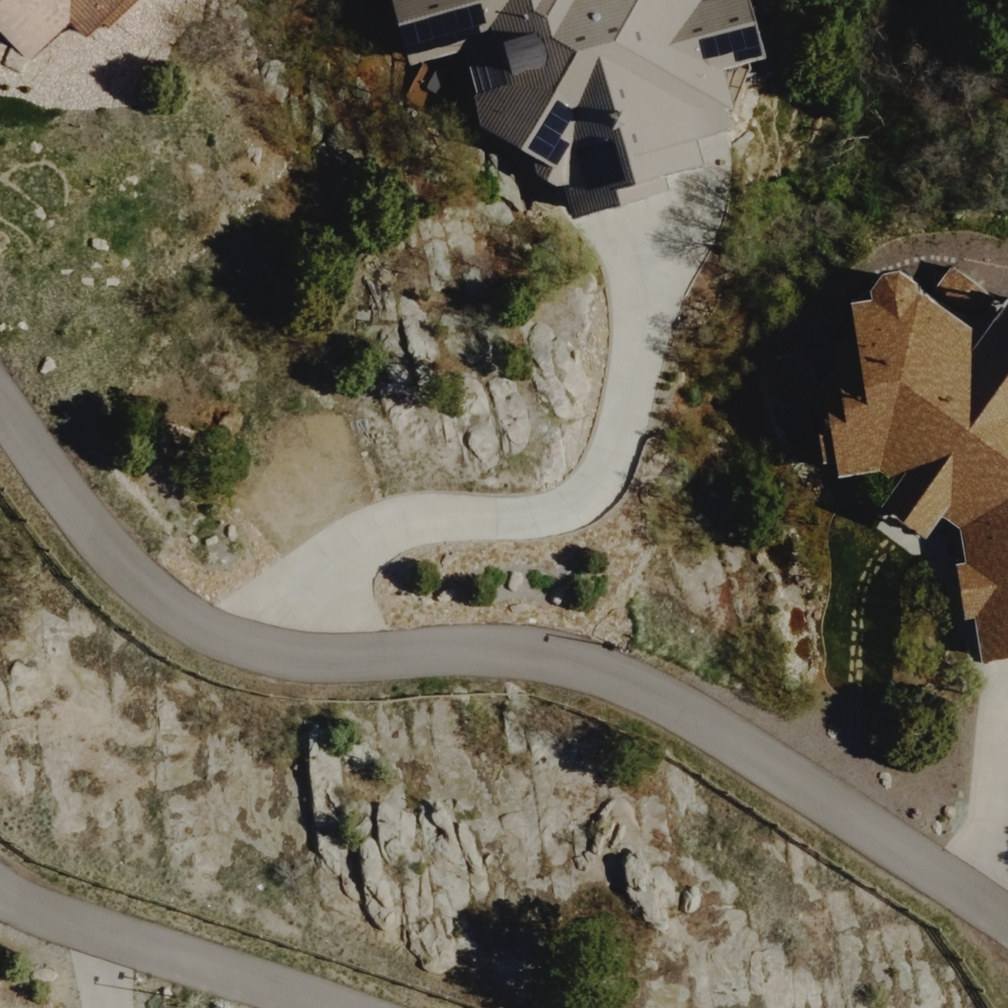

In [9]:
tile

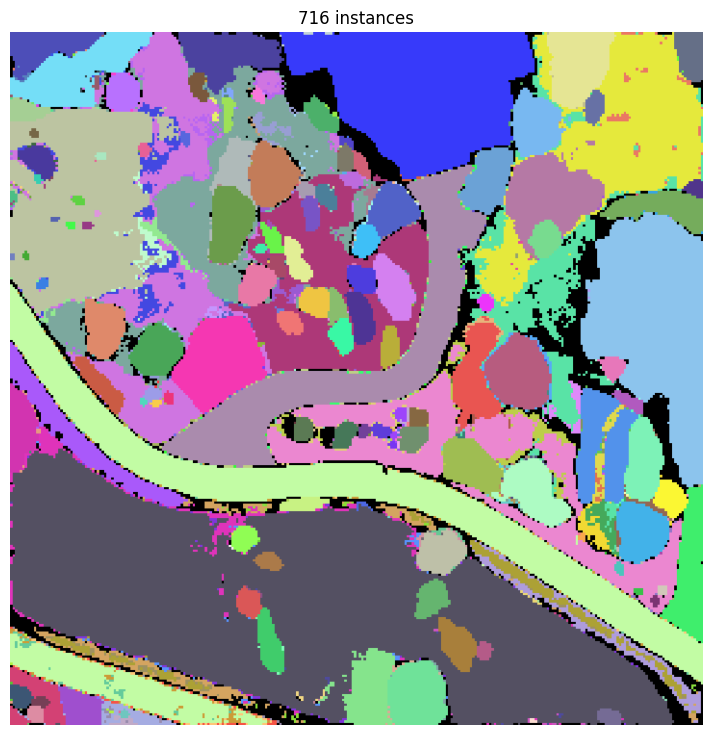

In [10]:
# Identity (instance) raster from dets: each detection is one instance with its own id and colour.
ids = np.zeros((MODEL_PX, MODEL_PX), np.int32)                 # 0 = background, else instance id
for i, d in enumerate(sorted(dets, key=lambda d: d[-2]), start=1):   # lower score first, higher overwrites
    m = np.asarray(Image.fromarray((d[-1] > 0).astype("uint8") * 255)
                   .resize((MODEL_PX, MODEL_PX), Image.NEAREST)) > 0
    ids[m] = i

n = int(ids.max())
rng = np.random.default_rng(0)
lut = np.vstack([[0, 0, 0], rng.uniform(0.2, 1.0, (n, 3))])    # background black, one colour per instance
plt.figure(figsize=(9, 9)); plt.imshow(lut[ids]); plt.axis("off")
plt.title(f"{n} instances"); plt.show()

In [40]:
256*0.075*0.075

1.44

In [14]:
# Object-tracking segmentation: windows follow objects, instances persist across window boundaries.
# State is a scene-sized id raster + score + interior-distance, all memmapped. Ends in per-class rasters + GPKG.
import os, glob, shutil, time, gc, random
import numpy as np
from collections import defaultdict
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.warp import transform as warp_transform
from rasterio.features import shapes as rio_shapes
from shapely.geometry import shape as shp_shape
from shapely.ops import unary_union
from scipy import ndimage
from pyproj import Geod

SCENE_IDX   = 1
TARGET_GSD  = 0.05     # metres per pixel the model sees
THRESH      = 0.50      # detection score cutoff
OVERLAP     = 0.5      # window overlap; step = MODEL_PX * (1 - OVERLAP)
CONTAIN     = 0.10      # shared / smaller-object pixels above this = same object
EDGE_MARGIN = 32         # mask within this many px of a window border is "open", queues growth
MIN_PX      = 16        # drop instances smaller than this at the end
MAX_WINDOWS = 40000      # hard guard
SEEDS       = 3         # random starting windows before coverage sweep takes over
WORK        = "/content/sam3_track"
CLASSRAS    = "/content/sam3_classras"
GPKG_OUT    = "/content/sam3_instances.gpkg"
GEOD = Geod(ellps="WGS84")
random.seed(0)

for d in (WORK, CLASSRAS):
    shutil.rmtree(d, ignore_errors=True); os.makedirs(d, exist_ok=True)

label, path = AOIS[SCENE_IDX]
print(f"scene: {label}")

def native_gsd_m(src):
    r, c = src.height // 2, src.width // 2
    (x0, y0), (x1, y1), (x2, y2) = src.xy(r, c), src.xy(r, c + 1), src.xy(r + 1, c)
    if src.crs is None:
        return abs(src.transform.a)
    lon, lat = warp_transform(src.crs, "EPSG:4326", [x0, x1, x2], [y0, y1, y2])
    dx = GEOD.inv(lon[0], lat[0], lon[1], lat[1])[2]
    dy = GEOD.inv(lon[0], lat[0], lon[2], lat[2])[2]
    return (dx + dy) / 2

def infer(tile):
    pv  = processor(images=tile, return_tensors="pt")["pixel_values"].to(device)
    txt = processor(text=PROMPTS, return_tensors="pt").to(device)
    with torch.no_grad(), torch.autocast(device, dtype=torch.bfloat16, enabled=device == "cuda"):
        vis = model.vision_encoder(pixel_values=pv)
        vis = type(vis)(
            fpn_hidden_states=tuple(t.expand(len(PROMPTS), *t.shape[1:]) for t in vis.fpn_hidden_states),
            fpn_position_encoding=tuple(t.expand(len(PROMPTS), *t.shape[1:]) for t in vis.fpn_position_encoding))
        outputs = model(vision_embeds=vis, input_ids=txt["input_ids"], attention_mask=txt["attention_mask"])
    res = processor.post_process_instance_segmentation(outputs, threshold=THRESH, mask_threshold=0.5, target_sizes=None)
    dets = [(CLASS_IDX[PROMPT_OF[pi][0]], float(s), m)
            for pi, r in enumerate(res)
            for m, s in zip(r["masks"].float().cpu().numpy(), r["scores"].float().cpu().numpy())]
    del pv, txt, vis, outputs, res
    return dets

# ── scene grid at the target GSD ───────────────────────────────────────────────
src = rasterio.open(path)
gsd = native_gsd_m(src)
W   = max(1, round(src.width  * gsd / TARGET_GSD))
H   = max(1, round(src.height * gsd / TARGET_GSD))
fx, fy = src.width / W, src.height / H
scene_tf = src.transform * Affine.scale(fx, fy)
P    = MODEL_PX
STEP = max(1, int(P * (1 - OVERLAP)))
print(f"{src.width}x{src.height} @ {gsd*100:.1f}cm -> scene {W}x{H} @ {TARGET_GSD*100:.1f}cm | "
      f"window {P}px step {STEP}px")

def mm(name, dtype, fill=0):
    a = np.memmap(f"{WORK}/{name}", mode="w+", dtype=dtype, shape=(H, W))
    a[:] = fill
    return a

ids      = mm("ids.dat",      np.int32,   0)     # instance id owning each pixel
score    = mm("score.dat",    np.float32, 0.0)   # its confidence
interior = mm("interior.dat", np.float32, -1.0)  # border distance of the window that painted it
visits   = mm("visits.dat",   np.uint8,   0)     # windows covering each pixel

# border distance, identical for every window since all are P x P
_d = np.minimum(np.arange(P), np.arange(P)[::-1]).astype(np.float32)
edge_d = np.minimum(_d[:, None], _d[None, :])

# ── catalogue + union-find ─────────────────────────────────────────────────────
cat    = {}          # id -> dict(cls, peak, px, obs)
parent = {}

def find(x):
    r = x
    while parent[r] != r:
        r = parent[r]
    while parent[x] != r:
        parent[x], x = r, parent[x]
    return r

def union(a, b):
    ra, rb = find(a), find(b)
    if ra == rb:
        return ra
    if rb < ra:
        ra, rb = rb, ra
    parent[rb] = ra
    ca, cb = cat[ra], cat[rb]
    ca["peak"] = max(ca["peak"], cb["peak"]); ca["px"] += cb["px"]; ca["obs"] += cb["obs"]
    del cat[rb]
    return ra

def read_window(ox, oy):
    w = Window(ox * fx, oy * fy, P * fx, P * fy)
    arr = src.read([1, 2, 3], window=w, out_shape=(3, P, P),
                   resampling=Resampling.bilinear, boundless=True, fill_value=0).astype("uint8")
    return Image.fromarray(np.moveaxis(arr, 0, -1))

def quant(ox, oy):
    """Snap an origin to the STEP lattice and clip into the scene. Keeps the frontier finite."""
    qx = min(max(0, int(round(ox / STEP)) * STEP), max(0, W - P))
    qy = min(max(0, int(round(oy / STEP)) * STEP), max(0, H - P))
    return qx, qy

# ── one window: infer, associate, merge, paint, queue growth ───────────────────
next_id = 1

def process(ox, oy):
    global next_id
    dets = infer(read_window(ox, oy))
    sub_ids = ids[oy:oy+P, ox:ox+P]
    pre = np.bincount(sub_ids.ravel())

    assigned = []      # (global_id, score, mask) for this window
    grow = set()
    for cidx, sc, m in dets:
        mask = np.asarray(Image.fromarray((m > 0).astype("uint8") * 255)
                          .resize((P, P), Image.NEAREST)) > 0
        npx = int(mask.sum())
        if npx == 0:
            continue

        # associate: existing ids under this mask, same class, by containment
        under = np.bincount(sub_ids[mask].ravel())
        hits = []
        for oid in np.nonzero(under)[0]:
            if oid == 0:
                continue
            r = find(int(oid))
            if r not in cat or cat[r]["cls"] != cidx:
                continue
            shared = int(under[oid])
            if shared / max(1, min(npx, cat[r]["px"])) >= CONTAIN:
                hits.append(r)

        if hits:
            gid = hits[0]
            for h in hits[1:]:                 # one mask spanning several ids means they are one object
                gid = union(gid, h)
            cat[gid]["peak"] = max(cat[gid]["peak"], sc)
            cat[gid]["obs"] += 1
        else:
            gid = next_id; next_id += 1
            parent[gid] = gid
            cat[gid] = dict(cls=cidx, peak=sc, px=npx, obs=1)

        assigned.append((gid, sc, mask))

        # open sides: mask reaches a window border, so the object continues past it
        e = EDGE_MARGIN
        if mask[:e, :].any():  grow.add((0, -1))
        if mask[-e:, :].any(): grow.add((0,  1))
        if mask[:, :e].any():  grow.add((-1, 0))
        if mask[:, -e:].any(): grow.add(( 1, 0))

    # window-local composite: higher score wins inside this window
    win_id  = np.zeros((P, P), np.int32)
    win_scr = np.zeros((P, P), np.float32)
    for gid, sc, mask in sorted(assigned, key=lambda x: x[1]):
        win_id[mask]  = gid
        win_scr[mask] = sc

    # scene paint: only where this window had more context than whatever painted before
    sub_int = interior[oy:oy+P, ox:ox+P]
    take = (win_id > 0) & (edge_d > sub_int)
    sub_ids[take]                       = win_id[take]
    score[oy:oy+P, ox:ox+P][take]       = win_scr[take]
    sub_int[take]                       = edge_d[take]
    visits[oy:oy+P, ox:ox+P] += 1

    # keep catalogue pixel counts exact for the containment test
    post = np.bincount(sub_ids.ravel())
    for oid in np.union1d(np.nonzero(pre)[0], np.nonzero(post)[0]):
        if oid == 0:
            continue
        r = find(int(oid))
        if r in cat:
            a = int(pre[oid]) if oid < len(pre) else 0
            b = int(post[oid]) if oid < len(post) else 0
            cat[r]["px"] = max(0, cat[r]["px"] + b - a)

    del dets
    return len(assigned), grow

# ── frontier: seeds, growth, then a coverage sweep for anything never looked at ─
lattice = [(x, y) for y in range(0, max(1, H - P) + 1, STEP)
                  for x in range(0, max(1, W - P) + 1, STEP)]
lattice = [quant(x, y) for x, y in lattice]
lattice = sorted(set(lattice))
print(f"lattice positions: {len(lattice)}")

seen  = set()
queue = [quant(*random.choice(lattice)) for _ in range(SEEDS)]
nwin = ndet = 0
t0 = time.perf_counter()

while queue and nwin < MAX_WINDOWS:
    ox, oy = queue.pop(0)
    if (ox, oy) in seen:
        continue
    seen.add((ox, oy))
    try:
        k, grow = process(ox, oy)
    except torch.cuda.OutOfMemoryError:
        gc.collect(); torch.cuda.empty_cache()
        print(f"OOM at ({ox},{oy}), skipping")
        continue
    nwin += 1; ndet += k

    for dx, dy in grow:                                   # extend toward every open side
        q = quant(ox + dx * STEP, oy + dy * STEP)
        if q not in seen:
            queue.append(q)

    if not queue:                                         # frontier spent: cover anything unseen
        for q in lattice:
            if q in seen:
                continue
            cy, cx = min(q[1] + P // 2, H - 1), min(q[0] + P // 2, W - 1)
            if visits[cy, cx] == 0:
                queue.append(q); break

    if nwin % 10 == 0:
        el = time.perf_counter() - t0
        print(f"\r  {nwin} windows | queue {len(queue)} | {len(cat)} objects | "
              f"{nwin/el*60:.1f} win/min", end="")
    if nwin % 20 == 0 and device == "cuda":
        torch.cuda.empty_cache()

el = time.perf_counter() - t0
cov = float((np.asarray(visits) > 0).mean())
print(f"\n{nwin} windows in {el:.0f}s, {ndet} detections, {len(cat)} tracked objects, "
      f"coverage {cov*100:.1f}%")

# ── resolve merges through the id raster in one pass ───────────────────────────
lut = np.zeros(next_id + 1, np.int32)
for i in range(1, next_id):
    if i in parent:
        lut[i] = find(i)
for r0 in range(0, H, 2048):                              # chunked so the memmap is not fully realised
    r1 = min(r0 + 2048, H)
    ids[r0:r1] = lut[ids[r0:r1]]

cls_lut = np.zeros(next_id + 1, np.int32)
for gid, rec in cat.items():
    cls_lut[gid] = rec["cls"] + 1                         # 1-based so 0 stays background

# ── per-class rasters + one GeoPackage ─────────────────────────────────────────
present = sorted({rec["cls"] for rec in cat.values()})
print(f"{len(present)} classes present")

rows = []
for cidx in present:
    keep = np.zeros(next_id + 1, bool)
    for gid, rec in cat.items():
        if rec["cls"] == cidx and rec["px"] >= MIN_PX:
            keep[gid] = True
    iid_c = np.where(keep[ids], np.asarray(ids), 0).astype(np.int32)
    if not iid_c.any():
        continue
    scr_c = np.where(iid_c > 0, np.asarray(score), 0).astype(np.float32)

    cname = CLASS_NAMES[cidx]
    with rasterio.open(f"{CLASSRAS}/{cidx:02d}_{cname}.tif", "w", driver="GTiff",
                       height=H, width=W, count=2, dtype="float32", crs=src.crs,
                       transform=scene_tf, nodata=0, compress="deflate") as dst:
        dst.write(scr_c, 1); dst.set_band_description(1, "score")
        dst.write(iid_c.astype(np.float32), 2); dst.set_band_description(2, "instance_id")

    by_id = {}
    for geom, v in rio_shapes(iid_c, mask=iid_c > 0, transform=scene_tf):
        by_id.setdefault(int(v), []).append(shp_shape(geom))
    for idv, polys in by_id.items():
        rec = cat.get(idv, {})
        rows.append({"iid": idv, "cls_id": cidx, "cls": cname,
                     "score": round(float(rec.get("peak", 0.0)), 4),
                     "obs": int(rec.get("obs", 0)),
                     "geometry": polys[0] if len(polys) == 1 else unary_union(polys)})
    del iid_c, scr_c

src.close()
out = gpd.GeoDataFrame(rows, geometry="geometry", crs=scene_tf and rasterio.open(path).crs)
out.to_file(GPKG_OUT, driver="GPKG")
print(f"{len(out)} instances -> {GPKG_OUT}")
print(f"per-class rasters -> {CLASSRAS}   (bands: 1 score, 2 instance_id)")
print(f"multi-window objects: {sum(1 for r in cat.values() if r['obs'] > 1)} of {len(cat)}")

scene: Castle Rock/Sample One/2025-05-12_us-co-denver-2025_sample_one.tif
7218x6387 @ 5.8cm -> scene 8325x7366 @ 5.0cm | window 1008px step 504px
lattice positions: 195
  220 windows | queue 2 | 7432 objects | 59.7 win/min
223 windows in 224s, 16014 detections, 7454 tracked objects, coverage 100.0%
15 classes present
3651 instances -> /content/sam3_instances.gpkg
per-class rasters -> /content/sam3_classras   (bands: 1 score, 2 instance_id)
multi-window objects: 1229 of 7454


In [16]:
# Grid swept once. Each object accumulates into its own array, growing to whatever bounds it needs,
# so a feature crossing any number of windows becomes one mask and nothing is overwritten in place.
import os, shutil, time, gc
import numpy as np
from collections import defaultdict
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.warp import transform as warp_transform
from rasterio.features import shapes as rio_shapes
from shapely.geometry import shape as shp_shape
from shapely.ops import unary_union
from pyproj import Geod

SCENE_IDX   = 1
TARGET_GSD  = 0.15      # metres per pixel the model sees
THRESH      = 0.50      # detection score cutoff
OVERLAP     = 0.50      # grid overlap; step = MODEL_PX * (1 - OVERLAP)
CONTAIN     = 0.10      # shared / smaller-mask pixels above this = same object
MIN_PX      = 16        # drop objects smaller than this at the end
WORK        = "/content/sam3_track"
CLASSRAS    = "/content/sam3_classras"
GPKG_OUT    = "/content/sam3_instances.gpkg"
GEOD = Geod(ellps="WGS84")

for d in (WORK, CLASSRAS):
    shutil.rmtree(d, ignore_errors=True); os.makedirs(d, exist_ok=True)

label, path = AOIS[SCENE_IDX]
print(f"scene: {label}")

def native_gsd_m(src):
    r, c = src.height // 2, src.width // 2
    (x0, y0), (x1, y1), (x2, y2) = src.xy(r, c), src.xy(r, c + 1), src.xy(r + 1, c)
    if src.crs is None:
        return abs(src.transform.a)
    lon, lat = warp_transform(src.crs, "EPSG:4326", [x0, x1, x2], [y0, y1, y2])
    dx = GEOD.inv(lon[0], lat[0], lon[1], lat[1])[2]
    dy = GEOD.inv(lon[0], lat[0], lon[2], lat[2])[2]
    return (dx + dy) / 2

def infer(tile):
    pv  = processor(images=tile, return_tensors="pt")["pixel_values"].to(device)
    txt = processor(text=PROMPTS, return_tensors="pt").to(device)
    with torch.no_grad(), torch.autocast(device, dtype=torch.bfloat16, enabled=device == "cuda"):
        vis = model.vision_encoder(pixel_values=pv)
        vis = type(vis)(
            fpn_hidden_states=tuple(t.expand(len(PROMPTS), *t.shape[1:]) for t in vis.fpn_hidden_states),
            fpn_position_encoding=tuple(t.expand(len(PROMPTS), *t.shape[1:]) for t in vis.fpn_position_encoding))
        outputs = model(vision_embeds=vis, input_ids=txt["input_ids"], attention_mask=txt["attention_mask"])
    res = processor.post_process_instance_segmentation(outputs, threshold=THRESH, mask_threshold=0.5, target_sizes=None)
    dets = [(CLASS_IDX[PROMPT_OF[pi][0]], float(s), m)
            for pi, r in enumerate(res)
            for m, s in zip(r["masks"].float().cpu().numpy(), r["scores"].float().cpu().numpy())]
    del pv, txt, vis, outputs, res
    return dets

# ── scene grid at the target GSD ───────────────────────────────────────────────
src = rasterio.open(path)
gsd = native_gsd_m(src)
W = max(1, round(src.width  * gsd / TARGET_GSD))
H = max(1, round(src.height * gsd / TARGET_GSD))
fx, fy = src.width / W, src.height / H
scene_tf, scene_crs = src.transform * Affine.scale(fx, fy), src.crs
P = MODEL_PX
STEP = max(1, int(P * (1 - OVERLAP)))

# the whole tile scheme, computed once and swept once
xs = list(range(0, max(1, W - P) + 1, STEP))
ys = list(range(0, max(1, H - P) + 1, STEP))
if xs[-1] != max(0, W - P): xs.append(max(0, W - P))     # flush the right edge
if ys[-1] != max(0, H - P): ys.append(max(0, H - P))     # flush the bottom edge
grid = [(x, y) for y in ys for x in xs]
print(f"{src.width}x{src.height} @ {gsd*100:.1f}cm -> scene {W}x{H} @ {TARGET_GSD*100:.1f}cm")
print(f"window {P}px step {STEP}px ({OVERLAP*100:.0f}% overlap) | {len(xs)}x{len(ys)} = {len(grid)} windows, one pass")

def read_window(ox, oy):
    w = Window(ox * fx, oy * fy, P * fx, P * fy)
    arr = src.read([1, 2, 3], window=w, out_shape=(3, P, P),
                   resampling=Resampling.bilinear, boundless=True, fill_value=0).astype("uint8")
    return Image.fromarray(np.moveaxis(arr, 0, -1))

# ── objects: each holds its own array and its own origin, free to grow anywhere ─
objs = {}                       # oid -> dict(cls, y0, x0, mask, peak, obs)
CELL = STEP
index = defaultdict(set)        # coarse cell -> candidate oids, to avoid scanning every object

def cells(y0, x0, y1, x1):
    for cy in range(y0 // CELL, (y1 - 1) // CELL + 1):
        for cx in range(x0 // CELL, (x1 - 1) // CELL + 1):
            yield (cy, cx)

def register(oid):
    r = objs[oid]
    h, w = r["mask"].shape
    for c in cells(r["y0"], r["x0"], r["y0"] + h, r["x0"] + w):
        index[c].add(oid)

def shared_px(rec, y0, x0, m):
    """Pixels the object and this mask hold in common."""
    ry0, rx0 = rec["y0"], rec["x0"]
    ry1, rx1 = ry0 + rec["mask"].shape[0], rx0 + rec["mask"].shape[1]
    iy0, ix0 = max(ry0, y0), max(rx0, x0)
    iy1, ix1 = min(ry1, y0 + m.shape[0]), min(rx1, x0 + m.shape[1])
    if iy1 <= iy0 or ix1 <= ix0:
        return 0
    a = rec["mask"][iy0 - ry0:iy1 - ry0, ix0 - rx0:ix1 - rx0]
    b = m[iy0 - y0:iy1 - y0, ix0 - x0:ix1 - x0]
    return int(np.count_nonzero(a & b))

def absorb(rec, y0, x0, m):
    """OR a mask into the object, expanding its own array to whatever bounds it now needs."""
    ry0, rx0 = rec["y0"], rec["x0"]
    ry1, rx1 = ry0 + rec["mask"].shape[0], rx0 + rec["mask"].shape[1]
    ny0, nx0 = min(ry0, y0), min(rx0, x0)
    ny1, nx1 = max(ry1, y0 + m.shape[0]), max(rx1, x0 + m.shape[1])
    if (ny0, nx0, ny1, nx1) != (ry0, rx0, ry1, rx1):        # the feature outgrew its array, so widen it
        big = np.zeros((ny1 - ny0, nx1 - nx0), bool)
        big[ry0 - ny0:ry1 - ny0, rx0 - nx0:rx1 - nx0] = rec["mask"]
        rec["mask"], rec["y0"], rec["x0"] = big, ny0, nx0
    rec["mask"][y0 - rec["y0"]:y0 - rec["y0"] + m.shape[0],
                x0 - rec["x0"]:x0 - rec["x0"] + m.shape[1]] |= m

# ── one pass over the grid ─────────────────────────────────────────────────────
next_id, ndet, t0 = 1, 0, time.perf_counter()
for n, (ox, oy) in enumerate(grid, start=1):
    try:
        dets = infer(read_window(ox, oy))
    except torch.cuda.OutOfMemoryError:
        gc.collect(); torch.cuda.empty_cache()
        print(f"\nOOM at ({ox},{oy}), skipping"); continue

    for cidx, sc, m in dets:
        mw = np.asarray(Image.fromarray((m > 0).astype("uint8") * 255)
                        .resize((P, P), Image.NEAREST)) > 0
        if not mw.any():
            continue
        ys_, xs_ = np.nonzero(mw)                            # crop to the mask's own bounds
        my0, my1 = int(ys_.min()), int(ys_.max()) + 1
        mx0, mx1 = int(xs_.min()), int(xs_.max()) + 1
        dm = mw[my0:my1, mx0:mx1]
        dy0, dx0 = oy + my0, ox + mx0
        npx = int(dm.sum())

        cand = set()
        for c in cells(dy0, dx0, dy0 + dm.shape[0], dx0 + dm.shape[1]):
            cand |= index[c]

        hits = []
        for oid in cand:
            rec = objs.get(oid)
            if rec is None or rec["cls"] != cidx:
                continue
            sh = shared_px(rec, dy0, dx0, dm)
            if sh and sh / max(1, min(npx, int(rec["mask"].sum()))) >= CONTAIN:
                hits.append(oid)

        if hits:
            gid = min(hits)
            rec = objs[gid]
            for h in hits:                                   # several pieces of one feature, joined by this view
                if h == gid:
                    continue
                o = objs.pop(h)
                absorb(rec, o["y0"], o["x0"], o["mask"])
                rec["peak"] = max(rec["peak"], o["peak"]); rec["obs"] += o["obs"]
            absorb(rec, dy0, dx0, dm)
            rec["peak"] = max(rec["peak"], sc); rec["obs"] += 1
        else:
            gid = next_id; next_id += 1
            objs[gid] = dict(cls=cidx, y0=dy0, x0=dx0, mask=dm.copy(), peak=sc, obs=1)
        register(gid)
        ndet += 1

    el = time.perf_counter() - t0
    print(f"\r  {n}/{len(grid)} windows | {len(objs)} objects | {ndet} detections | "
          f"{n/el*60:.1f} win/min", end="")
    del dets
    if n % 20 == 0 and device == "cuda":
        torch.cuda.empty_cache()

el = time.perf_counter() - t0
mb = sum(o["mask"].nbytes for o in objs.values()) / 1e6
print(f"\n{len(grid)} windows in {el:.0f}s, {ndet} detections, {len(objs)} objects, "
      f"{mb:.0f} MB of object masks")
print(f"multi-window objects: {sum(1 for o in objs.values() if o['obs'] > 1)} of {len(objs)}")

# ── output: per-class rasters, plus polygons cut from each object's own mask ────
by_cls = defaultdict(list)
for oid, rec in objs.items():
    if int(rec["mask"].sum()) >= MIN_PX:
        by_cls[rec["cls"]].append(oid)
print(f"{len(by_cls)} classes present, {sum(len(v) for v in by_cls.values())} objects kept")

rows = []
for cidx, oids in sorted(by_cls.items()):
    iid = np.memmap(f"{WORK}/iid.dat", mode="w+", dtype=np.int32,   shape=(H, W)); iid[:] = 0
    scr = np.memmap(f"{WORK}/scr.dat", mode="w+", dtype=np.float32, shape=(H, W)); scr[:] = 0
    # large first, small last, so a small feature sitting inside a large one still shows
    for oid in sorted(oids, key=lambda o: -int(objs[o]["mask"].sum())):
        rec = objs[oid]
        h, w = rec["mask"].shape
        y0, x0 = rec["y0"], rec["x0"]
        y1, x1 = min(H, y0 + h), min(W, x0 + w)
        if y1 <= y0 or x1 <= x0:
            continue
        sub = rec["mask"][:y1 - y0, :x1 - x0]
        iid[y0:y1, x0:x1][sub] = oid
        scr[y0:y1, x0:x1][sub] = rec["peak"]

    cname = CLASS_NAMES[cidx]
    with rasterio.open(f"{CLASSRAS}/{cidx:02d}_{cname}.tif", "w", driver="GTiff",
                       height=H, width=W, count=2, dtype="float32", crs=scene_crs,
                       transform=scene_tf, nodata=0, compress="deflate") as dst:
        dst.write(np.asarray(scr),                 1); dst.set_band_description(1, "score")
        dst.write(np.asarray(iid).astype("float32"), 2); dst.set_band_description(2, "instance_id")

    # polygons come from each object's own array, so overlapping features both survive intact
    for oid in oids:
        rec = objs[oid]
        tf = scene_tf * Affine.translation(rec["x0"], rec["y0"])
        mm8 = rec["mask"].astype("uint8")
        polys = [shp_shape(g) for g, v in rio_shapes(mm8, mask=rec["mask"], transform=tf) if v == 1]
        if not polys:
            continue
        rows.append({"iid": oid, "cls_id": cidx, "cls": cname,
                     "score": round(float(rec["peak"]), 4),
                     "obs": int(rec["obs"]),
                     "px": int(rec["mask"].sum()),
                     "geometry": polys[0] if len(polys) == 1 else unary_union(polys)})
    del iid, scr

src.close()
out = gpd.GeoDataFrame(rows, geometry="geometry", crs=scene_crs)
out.to_file(GPKG_OUT, driver="GPKG")
print(f"{len(out)} instances -> {GPKG_OUT}")
print(f"per-class rasters -> {CLASSRAS}   (bands: 1 score, 2 instance_id)")

scene: Castle Rock/Sample One/2025-05-12_us-co-denver-2025_sample_one.tif
7218x6387 @ 5.8cm -> scene 2775x2455 @ 15.0cm
window 1008px step 504px (50% overlap) | 5x4 = 20 windows, one pass
  20/20 windows | 978 objects | 5528 detections | 28.2 win/min
20 windows in 43s, 5528 detections, 978 objects, 46 MB of object masks
multi-window objects: 831 of 978
14 classes present, 978 objects kept
978 instances -> /content/sam3_instances.gpkg
per-class rasters -> /content/sam3_classras   (bands: 1 score, 2 instance_id)
